In [36]:

!pip install kaggle pandas matplotlib numpy -q

import os
import re
import time
import random
import zipfile
import glob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("All imports done.")
print(f"Access date: {datetime.today().strftime('%Y-%m-%d')}")

All imports done.
Access date: 2026-03-14


In [37]:

SUBSAMPLE        = True
MAX_COMMENTS     = 30000

K_SHINGLE        = 5
N_HASH           = 128
N_BANDS          = 32
ROWS_PER_BAND    = N_HASH // N_BANDS
SIMILARITY_THRESHOLD = 0.5
TOP_N             = 15
RANDOM_SEED       = 42

assert N_HASH % N_BANDS == 0, "N_HASH must be divisible by N_BANDS"
random.seed(RANDOM_SEED)

theoretical_thresh = (1.0 / N_BANDS) ** (1.0 / ROWS_PER_BAND)

print("=" * 50)
print(f"  Corpus           : NYT Comments 2020")
print(f"  MAX_COMMENTS     : {MAX_COMMENTS:,}")
print(f"  K_SHINGLE        : {K_SHINGLE}")
print(f"  N_HASH           : {N_HASH}")
print(f"  N_BANDS / R      : {N_BANDS} bands × {ROWS_PER_BAND} rows")
print(f"  LSH threshold    : (1/b)^(1/r) = {theoretical_thresh:.3f}")
print(f"  SIM threshold    : {SIMILARITY_THRESHOLD}")
print("=" * 50)

  Corpus           : NYT Comments 2020
  MAX_COMMENTS     : 30,000
  K_SHINGLE        : 5
  N_HASH           : 128
  N_BANDS / R      : 32 bands × 4 rows
  LSH threshold    : (1/b)^(1/r) = 0.420
  SIM threshold    : 0.5


In [24]:

os.environ['KAGGLE_USERNAME'] = "KAGGLE_USERNAME"
os.environ['KAGGLE_KEY']      = "KAGGLE_KEY"

!kaggle datasets download -d benjaminawd/new-york-times-articles-comments-2020 --force

os.makedirs('nyt_data', exist_ok=True)
with zipfile.ZipFile('new-york-times-articles-comments-2020.zip', 'r') as z:
    z.extractall('nyt_data')

all_files = sorted(set(
    glob.glob('nyt_data/**/*.csv', recursive=True) +
    glob.glob('nyt_data/*.csv')
))
print("Extracted files:")
for f in all_files:
    print(f"  {f}  ({os.path.getsize(f)/1e6:.1f} MB)")

Dataset URL: https://www.kaggle.com/datasets/benjaminawd/new-york-times-articles-comments-2020
License(s): CC-BY-NC-SA-4.0
 99% 1.92G/1.95G [00:11<00:00, 236MB/s]
100% 1.95G/1.95G [00:13<00:00, 160MB/s]
Extracted files:
  nyt_data/nyt-articles-2020.csv  (7.9 MB)
  nyt_data/nyt-comments-2020.csv  (3066.9 MB)
  nyt_data/nyt-comments-part0.csv  (303.3 MB)
  nyt_data/nyt-comments-part1.csv  (303.5 MB)
  nyt_data/nyt-comments-part2.csv  (302.0 MB)
  nyt_data/nyt-comments-part3.csv  (309.7 MB)
  nyt_data/nyt-comments-part4.csv  (309.0 MB)
  nyt_data/nyt-comments-part5.csv  (309.9 MB)
  nyt_data/nyt-comments-part6.csv  (308.5 MB)
  nyt_data/nyt-comments-part7.csv  (311.6 MB)
  nyt_data/nyt-comments-part8.csv  (310.9 MB)
  nyt_data/nyt-comments-part9.csv  (298.6 MB)
  nyt_data/test.csv  (1.9 MB)
  nyt_data/train.csv  (6.0 MB)


In [25]:
comment_files = sorted(set(glob.glob('nyt_data/nyt-comments-part*.csv')))
print(f"Part files found: {len(comment_files)}")

per_file = MAX_COMMENTS // max(len(comment_files), 1)
chunks   = []
for f in comment_files:
    try:
        chunk = pd.read_csv(
            f, encoding='utf-8', on_bad_lines='skip',
            usecols=['commentID', 'commentBody', 'articleID', 'userDisplayName'],
            dtype=str, nrows=per_file
        )
        chunks.append(chunk)
        print(f"  ✓ {f}  →  {len(chunk):,} rows")
    except Exception as e:
        print(f"  ✗ {f}  →  skipped: {e}")

comments_df = pd.concat(chunks, ignore_index=True)
print(f"\nTotal comments loaded : {len(comments_df):,}")
comments_df.head(3)

Part files found: 10
  ✓ nyt_data/nyt-comments-part0.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part1.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part2.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part3.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part4.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part5.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part6.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part7.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part8.csv  →  3,000 rows
  ✓ nyt_data/nyt-comments-part9.csv  →  3,000 rows

Total comments loaded : 30,000


,commentID,userDisplayName,commentBody,articleID
0,104387472,magicisnotreal,Here is something I think is fraudulent that v...,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...
1,104387873,JD,@magicisnotreal I have used my VA loan option...,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...
2,104387976,ebmem,@magi\n\nWhy would someone take out a VA loan ...,nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3...


In [26]:
# Clean
comments_df = comments_df.dropna(subset=['commentBody'])
comments_df = comments_df.drop_duplicates(subset='commentID')
comments_df = comments_df.reset_index(drop=True)

# Lowercase text for shingling (algorithm input)
comments_df['text'] = (
    comments_df['commentBody']
    .astype(str)
    .str.lower()
    .str.strip()
)

# Remove very short comments:not enough shingles to be meaningful
comments_df = comments_df[comments_df['text'].str.len() >= 80].reset_index(drop=True)

# Keep display friendly originals
comments_df['body_display'] = comments_df['commentBody'].astype(str).str.strip()
comments_df['article_ref']  = comments_df['articleID'].fillna('unknown')
comments_df['user_display'] = comments_df['userDisplayName'].fillna('Anonymous')

print(f"Comments after cleaning : {len(comments_df):,}")
print(f"Sample text             : {comments_df['text'].iloc[0][:120]}")

Comments after cleaning : 26,630
Sample text             : here is something i think is fraudulent that vets are subject to
 if you use your va home loan option you have to pay hi


In [27]:
#  Build corpus from comments
corpus_df = comments_df[['commentID', 'text',
                          'body_display', 'article_ref',
                          'user_display']].copy()

if SUBSAMPLE:
    indices = list(range(len(corpus_df)))
    random.shuffle(indices)
    indices = sorted(indices[:min(MAX_COMMENTS, len(corpus_df))])
    corpus_df = corpus_df.iloc[indices].reset_index(drop=True)

docs          = corpus_df['text'].tolist()
doc_ids       = corpus_df['commentID'].tolist()
bodies        = corpus_df['body_display'].tolist()
article_refs  = corpus_df['article_ref'].tolist()

N_DOCS        = len(docs)

print(f"Working corpus   : {N_DOCS:,} comments")
print(f"Sample comment   : {bodies[0][:150]}")
print(f"From article     : {article_refs[0]}")


Working corpus   : 26,630 comments
Sample comment   : Here is something I think is fraudulent that vets are subject to
 If you use your VA home loan option you have to pay higher interest rates regardless
From article     : nyt://article/69a7090b-9f36-569e-b5ab-b0ba5bb3ccbd
By user          : magicisnotreal


In [28]:
HASH_PRIME = 2_147_483_647   # Mersenne prime 2^31 - 1
HASH_BASE  = 31

def hash_func(text: str) -> int:

    h = 0
    for ch in text:
        h = (h * HASH_BASE + ord(ch)) % HASH_PRIME
    return h

# Quick  check
assert hash_func("hello") != hash_func("world")
assert hash_func("hello") == hash_func("hello")
print(f"poly_hash('hello') = {hash_func('hello')}")
print(f"poly_hash('world') = {hash_func('world')}")
print("Hash function OK ✓")

poly_hash('hello') = 99162322
poly_hash('world') = 113318802
Hash function OK ✓


In [29]:
def preprocess_text(text: str) -> str:
    """Normalise: lowercase, remove non-alphanumeric, collapse spaces."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def shingle_document(text: str, k: int) -> set:
    """
    Convert text to a set of hashed k-shingles.
    """
    text = preprocess_text(text)
    shingles = set()
    for i in range(len(text) - k + 1):
        shingles.add(hash_func(text[i : i + k]))
    return shingles

def jaccard_similarity(set_a: set, set_b: set) -> float:
    """True Jaccard: |A∩B| / |A∪B|. MMDS §3.1"""
    if not set_a and not set_b:
        return 1.0
    intersection = len(set_a & set_b)
    union        = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0

#  Build shingle sets
print(f"Shingling {N_DOCS:,} comments with k={K_SHINGLE} ...")
t0 = time.time()
shingle_sets = [shingle_document(doc, K_SHINGLE) for doc in docs]
elapsed = time.time() - t0

sizes = [len(s) for s in shingle_sets]
print(f"Done in {elapsed:.2f}s")
print(f"Shingle set size — min:{min(sizes)}  max:{max(sizes)}  mean:{sum(sizes)//len(sizes)}")
print(f"Sample shingle set (first 5 values): {list(shingle_sets[0])[:5]}")

Shingling 26,630 comments with k=5 ...
Done in 19.68s
Shingle set size — min:53  max:1296  mean:366
Sample shingle set (first 5 values): [109619712, 33267713, 102650881, 111055362, 33094658]


In [30]:
# minhashing
class LCG:
    """LCG: x_{n+1} = (A·x + C) mod M  — Numerical Recipes constants."""
    A = 1_664_525
    C = 1_013_904_223
    M = 2 ** 32

    def __init__(self, seed: int):
        self.state = seed % self.M

    def next_int(self) -> int:
        self.state = (self.A * self.state + self.C) % self.M
        return self.state

    def next_int_in(self, lo: int, hi: int) -> int:
        return lo + (self.next_int() % (hi - lo))

    def generate_pairs(self, n: int, lo: int, hi: int):
        return [(self.next_int_in(lo, hi), self.next_int_in(lo, hi)) for _ in range(n)]



class MinHasher:

    PRIME = 2_147_483_647

    def __init__(self, n_hash: int, seed: int = 42):
        self.n_hash = n_hash
        lcg = LCG(seed=seed)
        pairs = lcg.generate_pairs(n_hash, lo=1, hi=self.PRIME)
        self.a_coeffs = [p[0] for p in pairs]
        self.b_coeffs = [p[1] for p in pairs]

    def signature(self, shingle_set: set) -> list:
        """Compute MinHash signature for one document."""
        if not shingle_set:
            return [0] * self.n_hash
        shingles_list = list(shingle_set)
        sig = []
        for i in range(self.n_hash):
            a, b, p = self.a_coeffs[i], self.b_coeffs[i], self.PRIME
            min_val = p
            for x in shingles_list:
                hval = (a * x + b) % p
                if hval < min_val:
                    min_val = hval
            sig.append(min_val)
        return sig

    def estimated_jaccard(self, sig_a: list, sig_b: list) -> float:
        """Estimate Jaccard from two signatures,fraction of matching positions."""
        matches = sum(1 for va, vb in zip(sig_a, sig_b) if va == vb)
        return matches / self.n_hash


# Compute all signatures
print(f"Computing MinHash signatures for {N_DOCS:,} comments ...")
minhash = MinHasher(n_hash=N_HASH, seed=RANDOM_SEED)
t0 = time.time()
signatures = [minhash.signature(s) for s in shingle_sets]
elapsed = time.time() - t0
print(f"Done in {elapsed:.2f}s")
print(f"Signature length : {len(signatures[0])} (= N_HASH = {N_HASH})")
print(f"Sample signature (first 8 values): {signatures[0][:8]}")

Computing MinHash signatures for 26,630 comments ...
Done in 338.68s
Signature length : 128 (= N_HASH = 128)
Sample signature (first 8 values): [3077678, 2733201, 16051125, 6531031, 8155171, 2116604, 4777960, 2624308]


In [31]:
class LSH:

    def __init__(self, n_bands: int, rows_per_band: int):
        self.b = n_bands
        self.r = rows_per_band
        self.buckets = None

    def fit(self, signatures: list):
        n_docs = len(signatures)
        assert len(signatures[0]) == self.b * self.r
        self.buckets = [dict() for _ in range(self.b)]
        for band_idx in range(self.b):
            row_start = band_idx * self.r
            row_end   = row_start + self.r
            for doc_idx in range(n_docs):
                key = (band_idx,) + tuple(signatures[doc_idx][row_start:row_end])
                if key not in self.buckets[band_idx]:
                    self.buckets[band_idx][key] = []
                self.buckets[band_idx][key].append(doc_idx)
        return self

    def candidate_pairs(self) -> set:
        candidates = set()
        for band_dict in self.buckets:
            for bucket_docs in band_dict.values():
                if len(bucket_docs) > 1:
                    sd = sorted(bucket_docs)
                    for ii in range(len(sd)):
                        for jj in range(ii + 1, len(sd)):
                            candidates.add((sd[ii], sd[jj]))
        return candidates




# Build LSH index
print(f"Building LSH index  ({N_BANDS} bands × {ROWS_PER_BAND} rows) ...")
t0 = time.time()
lsh        = LSH(n_bands=N_BANDS, rows_per_band=ROWS_PER_BAND)
lsh.fit(signatures)
candidates = lsh.candidate_pairs()
lsh_build_time = time.time() - t0

total_pairs = N_DOCS * (N_DOCS - 1) // 2
reduction   = (total_pairs - len(candidates)) / total_pairs * 100 if total_pairs else 0

print(f"LSH index built in     : {lsh_build_time:.2f}s")
print(f"Total possible pairs   : {total_pairs:,}")
print(f"Candidate pairs        : {len(candidates):,}")
print(f"Comparisons reduced by : {reduction:.2f}%")

Building LSH index  (32 bands × 4 rows) ...
LSH index built in     : 5.03s
Total possible pairs   : 354,565,135
Candidate pairs        : 8,617
Comparisons reduced by : 100.00%


In [32]:
def find_similar_pairs(candidates: set, signatures: list,
                        minhash: MinHasher, threshold: float) -> list:

    similar = []
    for i, j in candidates:
        sim = minhash.estimated_jaccard(signatures[i], signatures[j])
        if sim >= threshold:
            similar.append((i, j, sim))
    similar.sort(key=lambda x: -x[2])
    return similar

print(f"Verifying {len(candidates):,} candidates  (threshold = {SIMILARITY_THRESHOLD}) ...")
t0 = time.time()
similar_pairs = find_similar_pairs(candidates, signatures, minhash, SIMILARITY_THRESHOLD)
verify_time = time.time() - t0

print(f"Verification done in : {verify_time:.2f}s")
print(f"Similar pairs found  : {len(similar_pairs):,}")
if not similar_pairs:
    print("No pairs found. Try lowering SIMILARITY_THRESHOLD in Section 1.")

Verifying 8,617 candidates  (threshold = 0.5) ...
Verification done in : 0.09s
Similar pairs found  : 243


In [33]:
def display_pair(rank: int, i: int, j: int, est_sim: float):
    """Rich display of one similar comment pair."""
    true_sim = jaccard_similarity(shingle_sets[i], shingle_sets[j])
    bar = lambda s: '█' * int(s * 20) + '░' * (20 - int(s * 20))

    print(f"{'='*72}")
    print(f"  RANK #{rank:02d}   MinHash Similarity = {est_sim:.4f}   True Jaccard = {true_sim:.4f}")
    print(f"  Similarity : [{bar(est_sim)}]")
    print(f"{'─'*72}")

    # Comment A
    shared_count = len(shingle_sets[i] & shingle_sets[j])
    union_count  = len(shingle_sets[i] | shingle_sets[j])
    print(f"  COMMENT A  │ ID: {doc_ids[i]}  │ Article: {article_refs[i]}")
    # print(f"  User       : {users[i]}")
    print(f"  Text       : {bodies[i][:250]}{'...' if len(bodies[i])>250 else ''}")
    print()

    # Comment B
    print(f"  COMMENT B  │ ID: {doc_ids[j]}  │ Article: {article_refs[j]}")
    # print(f"  User       : {users[j]}")
    print(f"  Text       : {bodies[j][:250]}{'...' if len(bodies[j])>250 else ''}")
    print()

    same_article = "Same article" if article_refs[i] == article_refs[j] else "📰 Different articles"
    print(f"  Overlap    : {shared_count} shared shingles / {union_count} total  →  {same_article}")
    print()


if similar_pairs:
    print(f"Found {len(similar_pairs):,} similar comment pairs above threshold {SIMILARITY_THRESHOLD}\n")
    for rank, (i, j, sim) in enumerate(similar_pairs[:TOP_N], 1):
        display_pair(rank, i, j, sim)
    if len(similar_pairs) > TOP_N:
        print(f"  ... and {len(similar_pairs) - TOP_N} more pairs (showing top {TOP_N})")
else:
    print(f"No pairs found above threshold={SIMILARITY_THRESHOLD}.")
    print("Lower SIMILARITY_THRESHOLD in Section 1 (try 0.3 or 0.2).")

Found 243 similar comment pairs above threshold 0.5

  RANK #01   MinHash Similarity = 1.0000   True Jaccard = 1.0000
  Similarity : [████████████████████]
────────────────────────────────────────────────────────────────────────
  COMMENT A  │ ID: 105041493  │ Article: nyt://article/bf13690b-edb9-5e3e-bce1-bc700c7313ea
  Text       : In defense of one mans criminal actions, a man who most GOP leaders and supporters rejected most of his life, the senate decided our constitution, our congress, our intelligence and our SCOTUS were irrelevant. 
Funny, they made the the best case poss...

  COMMENT B  │ ID: 105041494  │ Article: nyt://article/bf13690b-edb9-5e3e-bce1-bc700c7313ea
  Text       : In defense of one mans criminal actions, a man who most GOP leaders and supporters rejected most of his life, the senate decided our constitution, our congress, our intelligence and our SCOTUS were irrelevant. 
Funny, they made the the best case poss...

  Overlap    : 278 shared shingles / 278 total 

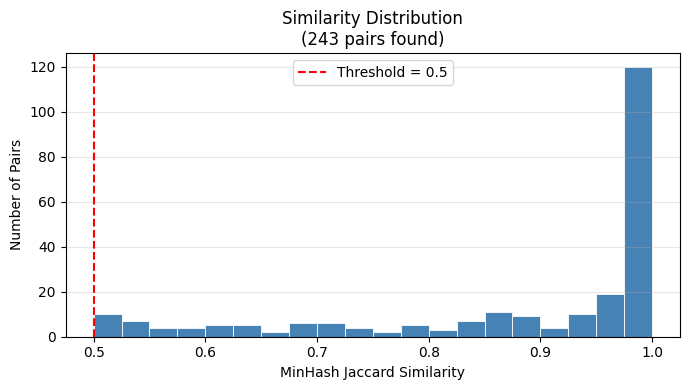

In [34]:
if similar_pairs:
    sim_scores = [s for _, _, s in similar_pairs]

    fig, ax = plt.subplots(figsize=(7, 4))

    # Similarity Score Distribution
    ax.hist(sim_scores, bins=20, color='steelblue', edgecolor='white', linewidth=0.6)
    ax.axvline(SIMILARITY_THRESHOLD, color='red', ls='--', lw=1.5,
               label=f'Threshold = {SIMILARITY_THRESHOLD}')

    ax.set_xlabel('MinHash Jaccard Similarity')
    ax.set_ylabel('Number of Pairs')
    ax.set_title(f'Similarity Distribution\n({len(similar_pairs):,} pairs found)')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    # plt.show()

else:
    print("No similar pairs to plot.")


In [35]:
print("=" * 55)
print("  FINDING SIMILAR COMMENTS — RESULTS SUMMARY")
print("=" * 55)
print(f"  Dataset        : NYT Comments 2020")
print(f"  Corpus size    : {N_DOCS:,} comments")
print(f"  Shingle size k : {K_SHINGLE}")
print(f"  Signatures     : {N_HASH} hash functions")
print(f"  LSH config     : b={N_BANDS} bands × r={ROWS_PER_BAND} rows")
print(f"  LSH threshold  : {theoretical_thresh:.3f}")
print(f"  Sim threshold  : {SIMILARITY_THRESHOLD}")
print("-" * 55)
print(f"  Total pairs    : {total_pairs:,}")
print(f"  Candidates     : {len(candidates):,}")
print(f"  Pairs reduced  : {reduction:.2f}%")
print(f"  Similar pairs  : {len(similar_pairs):,}")
print("-" * 55)



  FINDING SIMILAR COMMENTS — RESULTS SUMMARY
  Dataset        : NYT Comments 2020
  Corpus size    : 26,630 comments
  Shingle size k : 5
  Signatures     : 128 hash functions
  LSH config     : b=32 bands × r=4 rows
  LSH threshold  : 0.420
  Sim threshold  : 0.5
-------------------------------------------------------
  Total pairs    : 354,565,135
  Candidates     : 8,617
  Pairs reduced  : 100.00%
  Similar pairs  : 243
-------------------------------------------------------
